In [1]:
import pandas as pd
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import mlflow
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

### Sample Size and Results (Linear Regression)

**Sample Size: 10,000**
- **Mean Squared Error:** 156.22820476030694
- **Mean Absolute Error:** 6.255310190192762
- **R2 Score:** 0.25155387861743084

**Sample Size: 100,000**
- **Mean Squared Error:** 52.35016930190934
- **Mean Absolute Error:** 3.3605203273978432
- **R2 Score:** 0.36299942786973993

**Sample Size: 1,000,000**
- **Mean Squared Error:** 49.56988919459355
- **Mean Absolute Error:** 3.1915723044665603
- **R2 Score:** 0.3551601295610247

### Random Forest Regressor Results:



In [2]:
x_train = pd.read_csv("data/x_train.csv")
y_train = pd.read_csv("data/y_train.csv")
x_test = pd.read_csv("data/x_test.csv")
y_test = pd.read_csv("data/y_test.csv")

In [3]:
mlflow.set_experiment("Linear Regression Basemodel")
mlflow.sklearn.autolog()
linearRegModel = LinearRegression()
linearRegModel.fit(x_train,y_train)
y_pred = linearRegModel.predict(x_test)

2026/07/17 10:13:20 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '32bae500d8234860a706c817859ff324', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/07/17 10:14:31 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\ApoorvTripathi\Desktop\length-of-stay-prediction-using-icp-codes\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing v

In [4]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')
print(f'R2 Score: {r2}')

Mean Squared Error: 0.21621434386061195
Mean Absolute Error: 0.3465099513498912
R2 Score: 0.6081954806072103


In [5]:
mlflow.set_experiment("Random Forest Regressor")
mlflow.sklearn.autolog()
rf = RandomForestRegressor(n_jobs=10,max_depth=10,n_estimators=200)
rf.fit(x_train,y_train)
y_pred = rf.predict(x_test)

2026/07/17 10:16:23 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '88a2966547504aa0b7c696c61e3a62b9', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/07/17 10:19:35 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\ApoorvTripathi\Desktop\length-of-stay-prediction-using-icp-codes\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing v

In [7]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')
print(f'R2 Score: {r2}')

Mean Squared Error: 0.044972559850001016
Mean Absolute Error: 0.14126782104486021
R2 Score: 0.9185047028644289


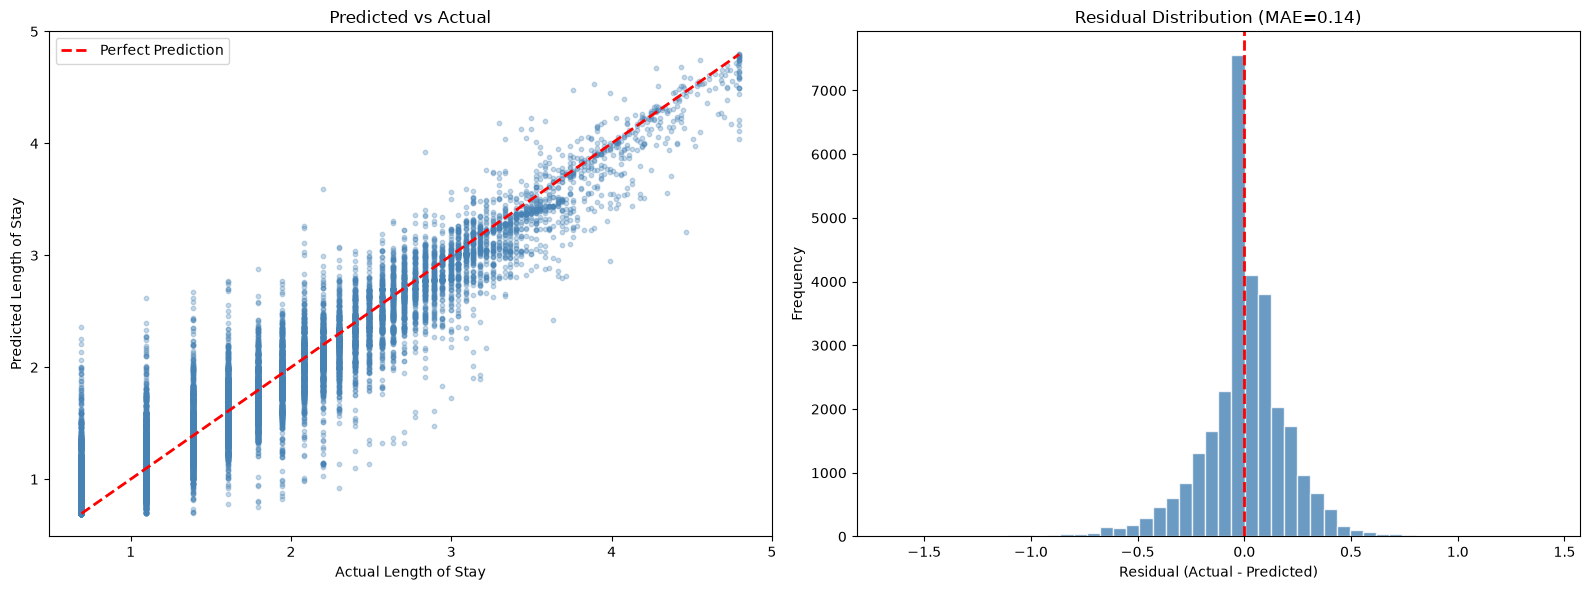

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Scatter — Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Length of Stay')
axes[0].set_ylabel('Predicted Length of Stay')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()

# Plot 2: Residual distribution
residuals = y_test.values.ravel() - y_pred.ravel()
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Residual Distribution (MAE={mae:.2f})')

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.inspection import permutation_importance

# Load data
x_train = pd.read_csv("data/x_train.csv")
y_train = pd.read_csv("data/y_train.csv").values.ravel()
x_test = pd.read_csv("data/x_test.csv")
y_test = pd.read_csv("data/y_test.csv").values.ravel()

# ========================================
# 1. Permutation Importance — Flag columns
#    that contribute disproportionate power
# ========================================
rf = RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
rf.fit(x_train, y_train)

perm_result = permutation_importance(rf, x_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)

# Build a summary DataFrame
perm_df = pd.DataFrame({
    "feature": x_train.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False)

# Flag features with suspiciously high importance
top_features = perm_df.head(20)
print("=== Top 20 Features by Permutation Importance ===")
print(top_features.to_string(index=False))
print()

# ========================================
# 2. Single-Feature R² — Any feature that
#    alone explains a large portion of the
#    target is a data leakage candidate
# ========================================
print("=== Single-Feature R² Leakage Check ===")
print(f"{'Feature':<60} {'R² (train→test)':>15}")
print("-" * 77)

leaky_candidates = []
for col in x_train.columns:
    from sklearn.linear_model import LinearRegression
    lr = LinearRegression()
    lr.fit(x_train[[col]], y_train)
    y_pred = lr.predict(x_test[[col]])
    r2 = r2_score(y_test, y_pred)
    if r2 > 0.10:  # Threshold: single feature explains >10% of variance
        leaky_candidates.append((col, r2))
        print(f"⚠️  {col:<58} {r2:>15.4f}")

if not leaky_candidates:
    print("✅ No single feature explains >10% of variance alone.")
else:
    print(f"\n🔴 {len(leaky_candidates)} column(s) flagged as potential leakage sources!")

# ========================================
# 3. Correlation with target — High linear
#    correlation can indicate leakage
# ========================================
print("\n=== High Correlation with Target (|r| > 0.3) ===")
correlations = x_train.corrwith(pd.Series(y_train, index=x_train.index)).abs().sort_values(ascending=False)
high_corr = correlations[correlations > 0.3]
if len(high_corr) > 0:
    for feat, corr in high_corr.items():
        print(f"⚠️  {feat:<58} |r| = {corr:.4f}")
else:
    print("✅ No features with |r| > 0.3 against the target.")


2026/07/17 10:46:06 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '1583aa70f4f946d7a460705812f6c98b', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/07/17 10:46:59 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\ApoorvTripathi\Desktop\length-of-stay-prediction-using-icp-codes\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing v